In [10]:
import tensorflow as tf

def count_records(file_path):
    return sum(1 for _ in tf.data.TFRecordDataset(file_path))

print(f"Train count: {count_records('../data/Damaged-package-2/train/package.tfrecord')}")
print(f"Validation count: {count_records('../data/Damaged-package-2/valid/package.tfrecord')}")
print(f"Test count: {count_records('../data/Damaged-package-2/test/package.tfrecord')}")

Train count: 288
Validation count: 27
Test count: 14


In [11]:
raw_dataset = tf.data.TFRecordDataset('../data/Damaged-package-2/train/package.tfrecord')
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    print("Keys found in your TFRecord:")
    for key in example.features.feature.keys():
        print(f"- {key}")

Keys found in your TFRecord:
- image/height
- image/object/bbox/ymin
- image/format
- image/object/bbox/xmax
- image/encoded
- image/width
- image/object/bbox/xmin
- image/filename
- image/object/class/text
- image/object/bbox/ymax
- image/object/class/label


In [12]:
from collections import Counter

def get_class_distribution(file_path):
    label_counts = Counter()
    
    feature_description = {
        'image/object/class/label': tf.io.VarLenFeature(tf.int64),
    }

    def _parse_label(proto):
        parsed_features = tf.io.parse_single_example(proto, feature_description)
        # convert the list of labels into array
        labels = tf.sparse.to_dense(parsed_features['image/object/class/label'])
        return labels

    dataset = tf.data.TFRecordDataset(file_path)
    for labels in dataset.map(_parse_label):
        # count every individual object found in the images
        for l in labels.numpy():
            label_counts[l] += 1
        
    return label_counts

id_map = {1: "Minor Damage (Damaged)", 2: "Severe Damage (Destroyed)", 3: "Intact"}

train_path = '../data/Damaged-package-2/train/package.tfrecord'
distribution = get_class_distribution(train_path)

print("Instance Distribution in Training Set:")
for label_id, count in distribution.items():
    print(f"{id_map.get(label_id, 'Unknown')}: {count} instances")

Instance Distribution in Training Set:
Severe Damage (Destroyed): 75 instances
Minor Damage (Damaged): 294 instances
Intact: 782 instances


In [13]:
def parse_to_classification(proto):
    feature_description = {
        'image/encoded': tf.io.FixedLenFeature([], tf.string),
        'image/object/class/label': tf.io.VarLenFeature(tf.int64),
    }
    parsed = tf.io.parse_single_example(proto, feature_description)
    
    # preprocessing
    image = tf.io.decode_jpeg(parsed['image/encoded'])
    image = tf.image.resize(image, [224, 224])
    image = image / 255.0 
    
    # (0=Intact, 1=Minor, 2=Severe)
    labels = tf.sparse.to_dense(parsed['image/object/class/label'])
    if tf.reduce_any(labels == 2):
        global_label = 2 
    elif tf.reduce_any(labels == 1):
        global_label = 1
    else:
        global_label = 0
        
    # one hot encoding
    one_hot_label = tf.one_hot(global_label, depth=3)
        
    return image, one_hot_label

In [14]:
total_instances = 1151 
n_classes = 3

# weight = total / (n_classes * count_in_class)
class_weights = {
    0: total_instances / (n_classes * 782), # Intact 
    1: total_instances / (n_classes * 294), # Minor Damage 
    2: total_instances / (n_classes * 75)   # Severe Damage 
}

print(f"Applying Class Weights: {class_weights}")

Applying Class Weights: {0: 0.4906223358908781, 1: 1.3049886621315192, 2: 5.115555555555556}


In [15]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# construct classifier
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), 
    layers.Dropout(0.2),             
    layers.Dense(3, activation='softmax') # for the 3 classes
])

# eval metrics 
metrics = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'), 
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
# create training pipeline
train_path = '../data/Damaged-package-2/train/package.tfrecord'
train_ds = tf.data.TFRecordDataset(train_path).map(parse_to_classification)
train_ds = train_ds.shuffle(100).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.TFRecordDataset('../data/Damaged-package-2/valid/package.tfrecord')
val_ds = val_ds.map(parse_to_classification).batch(32).prefetch(tf.data.AUTOTUNE)

# run training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 297ms/step - accuracy: 0.3889 - loss: 2.2757 - precision: 0.4008 - recall: 0.3576 - val_accuracy: 0.6667 - val_loss: 0.8997 - val_precision: 0.6667 - val_recall: 0.6667
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.5764 - loss: 1.5166 - precision: 0.5754 - recall: 0.5694 - val_accuracy: 0.7037 - val_loss: 0.9260 - val_precision: 0.7037 - val_recall: 0.7037
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 0.6424 - loss: 1.2018 - precision: 0.6424 - recall: 0.6424 - val_accuracy: 0.6296 - val_loss: 0.9595 - val_precision: 0.6296 - val_recall: 0.6296
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.7292 - loss: 1.0136 - precision: 0.7292 - recall: 0.7292 - val_accuracy: 0.7037 - val_loss: 0.9243 - val_precision: 0.7037 - val_recall: 0.7037
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 0.8264 - loss: 0.8177 - precision: 0.8264 - recall: 0.8264 - val_accuracy: 0.7037 - val_loss: 0.9527 - val

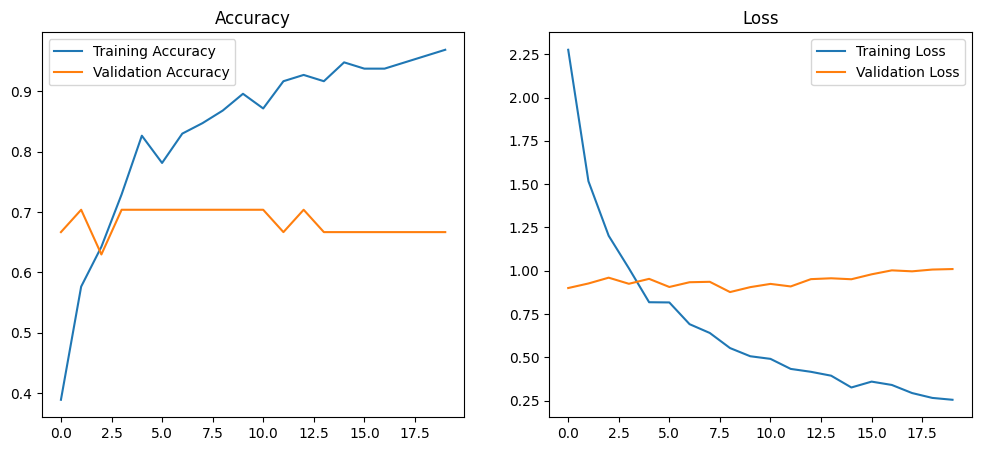

In [17]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


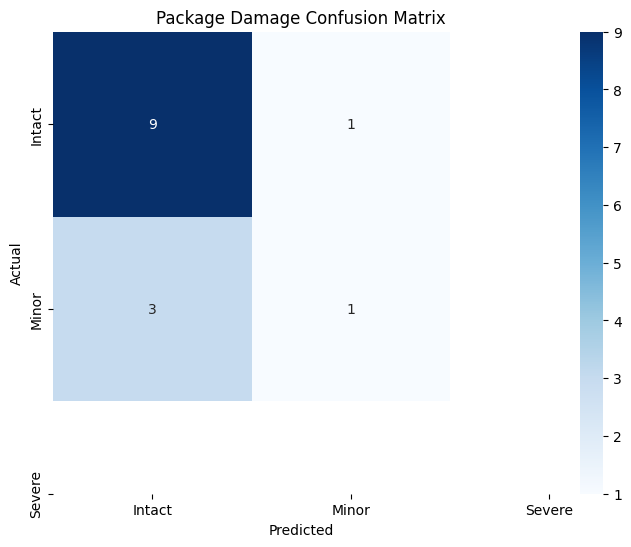

              precision    recall  f1-score   support

      Intact       0.00      0.00      0.00         0
       Minor       0.75      0.90      0.82        10
      Severe       0.50      0.25      0.33         4

    accuracy                           0.71        14
   macro avg       0.42      0.38      0.38        14
weighted avg       0.68      0.71      0.68        14



/Users/cha/CS/CS180/RipEye/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cha/CS/CS180/RipEye/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cha/CS/CS180/RipEye/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# get predictions and true labels
test_ds = tf.data.TFRecordDataset('../data/Damaged-package-2/test/package.tfrecord')
test_ds = test_ds.map(parse_to_classification).batch(32)

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Intact', 'Minor', 'Severe'],
            yticklabels=['Intact', 'Minor', 'Severe'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Package Damage Confusion Matrix')
plt.show()

print(classification_report(
    y_true, 
    y_pred, 
    labels=[0, 1, 2], 
    target_names=['Intact', 'Minor', 'Severe']
))